In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from google.colab import drive
drive.mount('/content/drive')

In [3]:
df = pd.read_csv("/content/drive/MyDrive/Project_NN/Data/Cleaned.csv")

X = df.drop(columns=["price_usd_log"]).values
y = df["price_usd_log"].values

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [5]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

In [7]:
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [9]:
class HousePriceModel(nn.Module):
    def __init__(self, input_size):
        super(HousePriceModel, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

model = HousePriceModel(X_train.shape[1]).to(device)

In [10]:
criterion = nn.HuberLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=8
)

In [11]:
criterion = nn.HuberLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=8
)

In [12]:
epochs = 200

train_losses = []
val_losses = []

best_loss = float('inf')
patience = 20
counter = 0

In [13]:
for epoch in range(epochs):

    model.train()

    running_loss = 0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        outputs = model(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * features.size(0)

    train_loss = running_loss / len(train_loader.dataset)


    model.eval()

    val_running_loss = 0

    with torch.no_grad():

        for features, labels in test_loader:

            features = features.to(device)
            labels = labels.to(device)

            outputs = model(features)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * features.size(0)

    val_loss = val_running_loss / len(test_loader.dataset)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")


    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0

        torch.save(model.state_dict(), "best_model.pth")

    else:
        counter += 1

        if counter >= patience:
            print("Early stopping triggered!")
            break

Epoch [1/200] Train Loss: 2.5389 Val Loss: 0.1616
Epoch [2/200] Train Loss: 0.1774 Val Loss: 0.1530
Epoch [3/200] Train Loss: 0.1677 Val Loss: 0.1518
Epoch [4/200] Train Loss: 0.1619 Val Loss: 0.1452
Epoch [5/200] Train Loss: 0.1591 Val Loss: 0.1455
Epoch [6/200] Train Loss: 0.1571 Val Loss: 0.1424
Epoch [7/200] Train Loss: 0.1545 Val Loss: 0.1415
Epoch [8/200] Train Loss: 0.1528 Val Loss: 0.1416
Epoch [9/200] Train Loss: 0.1519 Val Loss: 0.1418
Epoch [10/200] Train Loss: 0.1512 Val Loss: 0.1378
Epoch [11/200] Train Loss: 0.1501 Val Loss: 0.1372
Epoch [12/200] Train Loss: 0.1498 Val Loss: 0.1392
Epoch [13/200] Train Loss: 0.1488 Val Loss: 0.1363
Epoch [14/200] Train Loss: 0.1477 Val Loss: 0.1410
Epoch [15/200] Train Loss: 0.1486 Val Loss: 0.1376
Epoch [16/200] Train Loss: 0.1476 Val Loss: 0.1372
Epoch [17/200] Train Loss: 0.1468 Val Loss: 0.1358
Epoch [18/200] Train Loss: 0.1466 Val Loss: 0.1352
Epoch [19/200] Train Loss: 0.1460 Val Loss: 0.1349
Epoch [20/200] Train Loss: 0.1456 Val Lo

In [16]:
model.load_state_dict(torch.load("best_model.pth"))

model.eval()

with torch.no_grad():

    predictions = model(X_test.to(device)).cpu().numpy()

y_true = y_test.numpy()

In [14]:
mse = mean_squared_error(y_true, predictions)
mae = mean_absolute_error(y_true, predictions)
r2 = r2_score(y_true, predictions)

print("\nEvaluation Metrics:")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")


Evaluation Metrics:
MSE: 0.2633
MAE: 0.3844
R2 Score: 0.5637


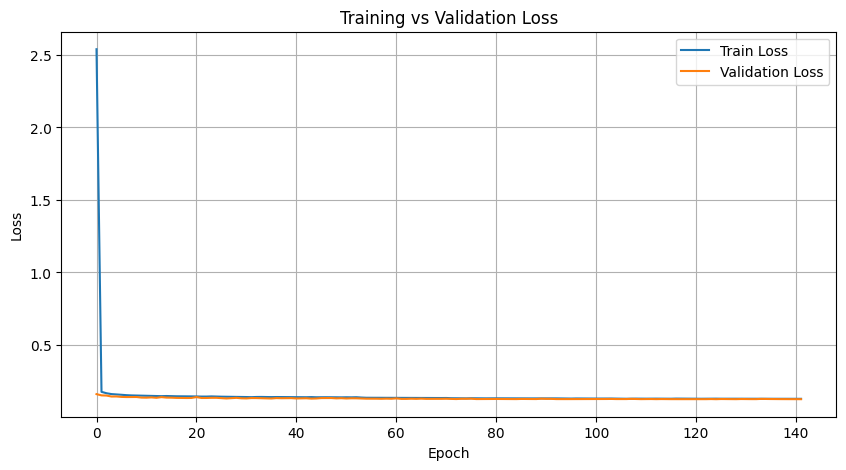

In [15]:
plt.figure(figsize=(10,5))

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

***Experimentations***

In [17]:
# MODEL B
# Activation Function = Tanh

class HousePriceModel_B(nn.Module):

    def __init__(self, input_size):

        super(HousePriceModel_B, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 256),
            nn.Tanh(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.Tanh(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),

            nn.Linear(128, 64),
            nn.Tanh(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.Tanh(),
            nn.BatchNorm1d(32),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

model_b = HousePriceModel_B(X_train.shape[1]).to(device)

criterion = nn.HuberLoss()

optimizer = torch.optim.Adam(
    model_b.parameters(),
    lr=0.001
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=8
)

epochs = 200

train_losses_b = []
val_losses_b = []

best_loss = float('inf')

patience = 20
counter = 0

for epoch in range(epochs):

    model_b.train()

    running_loss = 0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        outputs = model_b(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * features.size(0)

    train_loss = running_loss / len(train_loader.dataset)


    model_b.eval()

    val_running_loss = 0

    with torch.no_grad():

        for features, labels in test_loader:

            features = features.to(device)
            labels = labels.to(device)

            outputs = model_b(features)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * features.size(0)

    val_loss = val_running_loss / len(test_loader.dataset)

    scheduler.step(val_loss)

    train_losses_b.append(train_loss)
    val_losses_b.append(val_loss)

    print(f"Model B - Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")


    if val_loss < best_loss:

        best_loss = val_loss
        counter = 0

        torch.save(model_b.state_dict(), "best_model_b.pth")

    else:

        counter += 1

        if counter >= patience:

            print("Early stopping triggered!")
            break

model_b.load_state_dict(torch.load("best_model_b.pth"))

model_b.eval()

with torch.no_grad():

    predictions_b = model_b(X_test.to(device)).cpu().numpy()

y_true = y_test.numpy()

mse_b = mean_squared_error(y_true, predictions_b)
mae_b = mean_absolute_error(y_true, predictions_b)
r2_b = r2_score(y_true, predictions_b)

print("\nMODEL B RESULTS")
print(f"MSE: {mse_b:.4f}")
print(f"MAE: {mae_b:.4f}")
print(f"R2 Score: {r2_b:.4f}")

Model B - Epoch [1/200] Train Loss: 2.5125 Val Loss: 0.1668
Model B - Epoch [2/200] Train Loss: 0.1760 Val Loss: 0.1565
Model B - Epoch [3/200] Train Loss: 0.1716 Val Loss: 0.1547
Model B - Epoch [4/200] Train Loss: 0.1669 Val Loss: 0.1525
Model B - Epoch [5/200] Train Loss: 0.1653 Val Loss: 0.1513
Model B - Epoch [6/200] Train Loss: 0.1646 Val Loss: 0.1554
Model B - Epoch [7/200] Train Loss: 0.1633 Val Loss: 0.1505
Model B - Epoch [8/200] Train Loss: 0.1619 Val Loss: 0.1476
Model B - Epoch [9/200] Train Loss: 0.1608 Val Loss: 0.1449
Model B - Epoch [10/200] Train Loss: 0.1608 Val Loss: 0.1444
Model B - Epoch [11/200] Train Loss: 0.1591 Val Loss: 0.1486
Model B - Epoch [12/200] Train Loss: 0.1580 Val Loss: 0.1454
Model B - Epoch [13/200] Train Loss: 0.1578 Val Loss: 0.1440
Model B - Epoch [14/200] Train Loss: 0.1569 Val Loss: 0.1481
Model B - Epoch [15/200] Train Loss: 0.1566 Val Loss: 0.1421
Model B - Epoch [16/200] Train Loss: 0.1559 Val Loss: 0.1398
Model B - Epoch [17/200] Train Lo

In [18]:
# MODEL C
# Activation Function = ReLU
# Hidden Layers = Bigger Network
# Learning Rate = 0.0005

class HousePriceModel_C(nn.Module):

    def __init__(self, input_size):

        super(HousePriceModel_C, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


model_c = HousePriceModel_C(X_train.shape[1]).to(device)

criterion = nn.HuberLoss()

optimizer = torch.optim.Adam(
    model_c.parameters(),
    lr=0.0005
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=8
)


epochs = 200

train_losses_c = []
val_losses_c = []

best_loss = float('inf')

patience = 20
counter = 0


for epoch in range(epochs):

    model_c.train()

    running_loss = 0

    for features, labels in train_loader:

        features = features.to(device)
        labels = labels.to(device)

        outputs = model_c(features)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        running_loss += loss.item() * features.size(0)

    train_loss = running_loss / len(train_loader.dataset)


    model_c.eval()

    val_running_loss = 0

    with torch.no_grad():

        for features, labels in test_loader:

            features = features.to(device)
            labels = labels.to(device)

            outputs = model_c(features)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * features.size(0)

    val_loss = val_running_loss / len(test_loader.dataset)

    scheduler.step(val_loss)

    train_losses_c.append(train_loss)
    val_losses_c.append(val_loss)

    print(f"Model C - Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {train_loss:.4f} "
          f"Val Loss: {val_loss:.4f}")


    if val_loss < best_loss:

        best_loss = val_loss
        counter = 0

        torch.save(model_c.state_dict(), "best_model_c.pth")

    else:

        counter += 1

        if counter >= patience:

            print("Early stopping triggered!")
            break


model_c.load_state_dict(torch.load("best_model_c.pth"))


model_c.eval()

with torch.no_grad():

    predictions_c = model_c(X_test.to(device)).cpu().numpy()

y_true = y_test.numpy()


mse_c = mean_squared_error(y_true, predictions_c)
mae_c = mean_absolute_error(y_true, predictions_c)
r2_c = r2_score(y_true, predictions_c)

print("\nMODEL C RESULTS")
print(f"MSE: {mse_c:.4f}")
print(f"MAE: {mae_c:.4f}")
print(f"R2 Score: {r2_c:.4f}")

Model C - Epoch [1/200] Train Loss: 4.8295 Val Loss: 0.1779
Model C - Epoch [2/200] Train Loss: 0.1911 Val Loss: 0.1606
Model C - Epoch [3/200] Train Loss: 0.1751 Val Loss: 0.1528
Model C - Epoch [4/200] Train Loss: 0.1675 Val Loss: 0.1488
Model C - Epoch [5/200] Train Loss: 0.1624 Val Loss: 0.1487
Model C - Epoch [6/200] Train Loss: 0.1593 Val Loss: 0.1496
Model C - Epoch [7/200] Train Loss: 0.1563 Val Loss: 0.1418
Model C - Epoch [8/200] Train Loss: 0.1542 Val Loss: 0.1404
Model C - Epoch [9/200] Train Loss: 0.1526 Val Loss: 0.1425
Model C - Epoch [10/200] Train Loss: 0.1509 Val Loss: 0.1380
Model C - Epoch [11/200] Train Loss: 0.1497 Val Loss: 0.1410
Model C - Epoch [12/200] Train Loss: 0.1483 Val Loss: 0.1378
Model C - Epoch [13/200] Train Loss: 0.1468 Val Loss: 0.1357
Model C - Epoch [14/200] Train Loss: 0.1466 Val Loss: 0.1382
Model C - Epoch [15/200] Train Loss: 0.1456 Val Loss: 0.1360
Model C - Epoch [16/200] Train Loss: 0.1447 Val Loss: 0.1385
Model C - Epoch [17/200] Train Lo

In [22]:
results = {
    "Model": ["Model A (ReLU)", "Model B (Tanh)", "Model C (Deep ReLU)"],

    "MSE": [mse, mse_b, mse_c],
    "MAE": [mae, mae_b, mae_c],
    "R2 Score": [r2, r2_b, r2_c],
}

df_results = pd.DataFrame(results)

print("\n Model Comparison Table:\n")
print(df_results)


 Model Comparison Table:

                 Model       MSE       MAE  R2 Score
0       Model A (ReLU)  0.263268  0.384382  0.563724
1       Model B (Tanh)  0.268568  0.389181  0.554942
2  Model C (Deep ReLU)  0.260478  0.380531  0.568348
